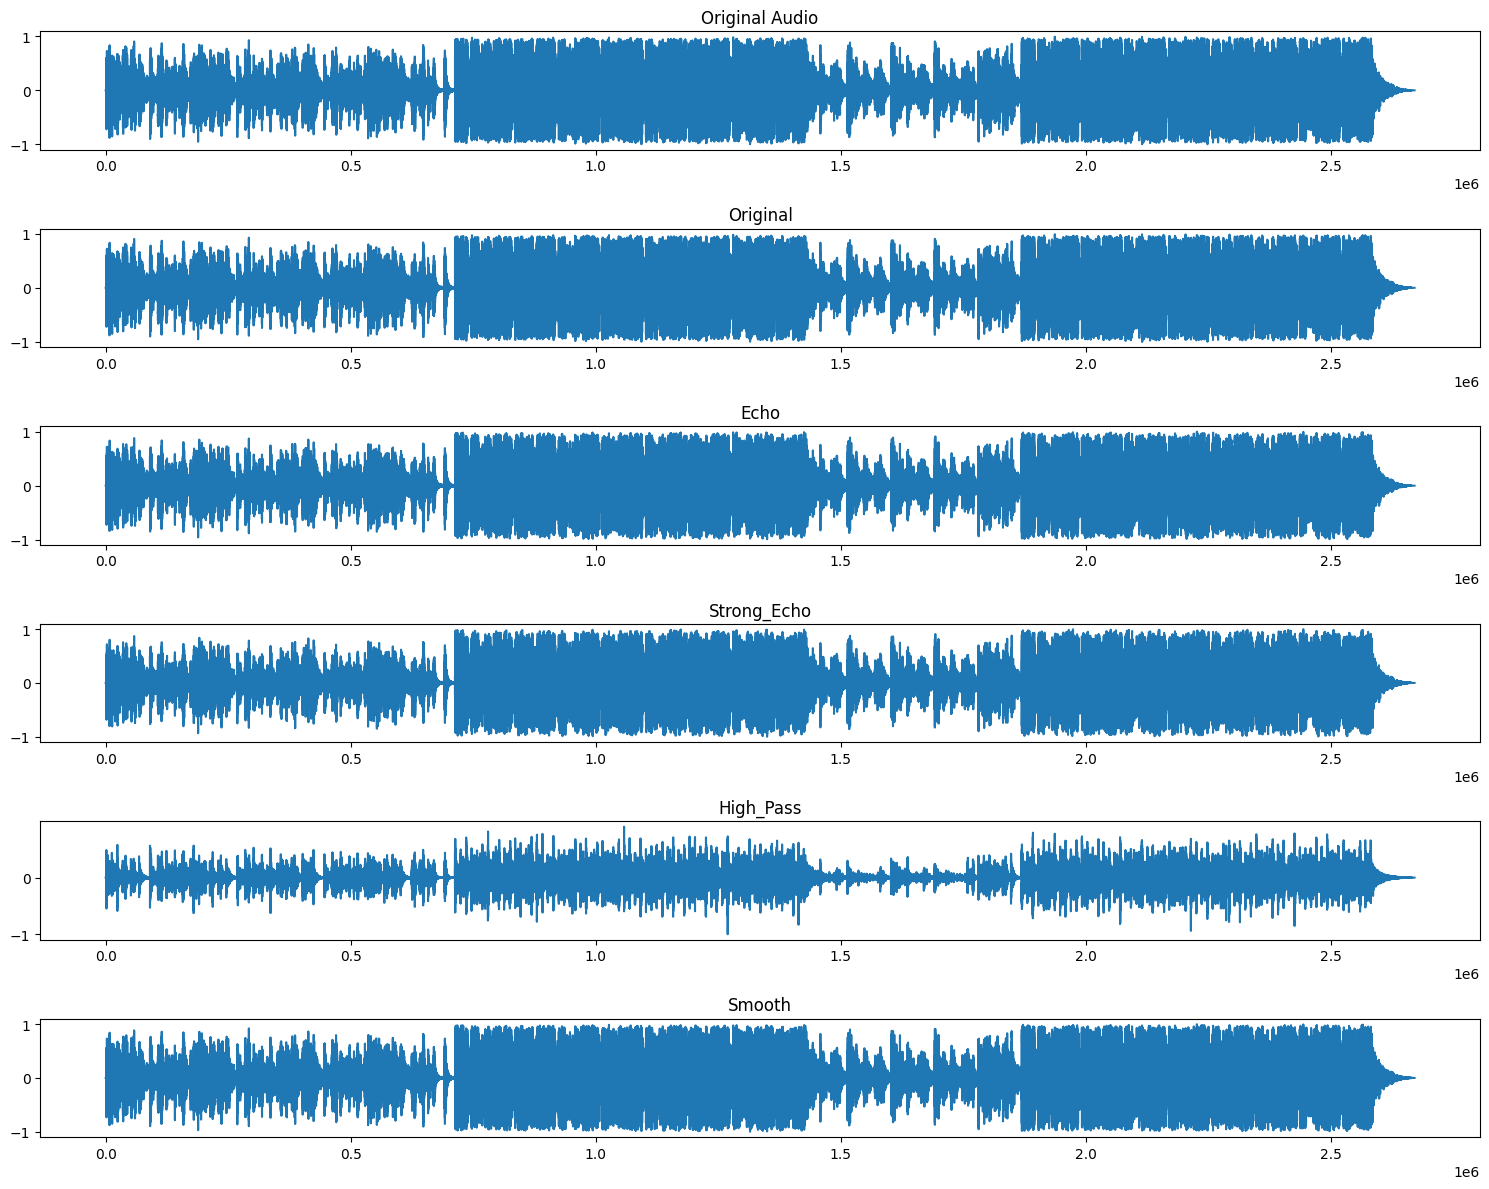

Processing Completed Successfully


In [1]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, lfilter

# -----------------------------
# Load Audio File
# -----------------------------
audio = AudioSegment.from_mp3("alec_koff-carnaval-484622.mp3")

# Convert to Mono
audio = audio.set_channels(1)

# Extract Samples
samples = np.array(audio.get_array_of_samples(), dtype=np.float32)

# Normalize
samples = samples / np.max(np.abs(samples))

# -----------------------------
# Define Different Impulse Responses
# -----------------------------
kernels = {
    "Original": np.array([1], dtype=np.float32),

    "Echo": np.array([1,0,1], dtype=np.float32),

    "Strong_Echo": np.array([1,0,1,0,1], dtype=np.float32),

    "High_Pass": np.array([1,-1], dtype=np.float32),

    "Smooth": np.array([0.2,0.6,0.2], dtype=np.float32)
}

plt.figure(figsize=(15,12))

plt.subplot(len(kernels)+1,1,1)
plt.plot(samples)
plt.title("Original Audio")

count=2

for name,kernel in kernels.items():

    output = convolve(samples,kernel,mode="same")

    output = output/np.max(np.abs(output))

    plt.subplot(len(kernels)+1,1,count)
    plt.plot(output)
    plt.title(name)

    output_int16=(output*32767).astype(np.int16)

    new_audio=AudioSegment(
        output_int16.tobytes(),
        frame_rate=audio.frame_rate,
        sample_width=2,
        channels=1
    )

    new_audio.export(f"{name}.wav",format="wav")

    count+=1

# -----------------------------
# Inverse Filtering
# -----------------------------
inverse_kernel=np.array([1,-0.5,0.25,-0.125,0.0625])

inverse=lfilter(inverse_kernel,[1],samples)

inverse=inverse/np.max(np.abs(inverse))

inverse_int16=(inverse*32767).astype(np.int16)

inverse_audio=AudioSegment(
    inverse_int16.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=2,
    channels=1
)

inverse_audio.export("Inverse_Filter_Output.wav",format="wav")

plt.tight_layout()

plt.show()

print("Processing Completed Successfully")